## Imports

In [81]:
import os
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models
from torchvision.io import read_image
from torchvision.transforms import v2

## Dataset

In [82]:
class SimpsonsDataset(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.classes = sorted(
            [d for d in os.listdir(self.path) if os.path.isdir(os.path.join(self.path, d))]
        )
        
        self.class_to_idx = {class_name: i for i, class_name in enumerate(self.classes)}

        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(self.path, class_name)

            for file_name in sorted(os.listdir(class_dir)):
                file_path = os.path.join(class_dir, file_name)

                if os.path.isfile(file_path):
                    self.samples.append((file_path, self.class_to_idx[class_name]))

    def __getitem__(self, index):
        image_path, label = self.samples[index]

        img = read_image(str(image_path))
        if self.transform is not None:
            img = self.transform(img)

        return img, label

    def __len__(self):
        return len(self.samples)

### Transforms + Augmentation

In [83]:
train_transform = v2.Compose([
    v2.RandomResizedCrop((224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=10),
    v2.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
])

val_transform = v2.Compose([
    v2.Resize((224, 224), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
])

### Load Dataset

In [84]:
PATH = "data/simpsons_dataset"
SEED = 42
RARE_THRESHOLD = 5

torch.manual_seed(SEED)
np.random.seed(SEED)

full_train_dataset = SimpsonsDataset(path=PATH, transform=train_transform)
full_val_dataset = SimpsonsDataset(path=PATH, transform=val_transform)

labels = [label for _, label in full_train_dataset.samples]
num_classes = len(full_train_dataset.classes)

print(f"Number of classes: {num_classes}")
print(f"Dataset size: {len(full_train_dataset)}")

Number of classes: 42
Dataset size: 20933


### Handle Rare Classes

In [85]:
class_counts = Counter(labels)
rare_classes = {cls for cls, count in class_counts.items() if count < RARE_THRESHOLD}

rare_indices = []
normal_indices = []

for i, label in enumerate(labels):
    if label in rare_classes:
        rare_indices.append(i)
    else:
        normal_indices.append(i)

normal_labels = [labels[i] for i in normal_indices]

train_idx_norm, temp_idx_norm = train_test_split(
    normal_indices,
    test_size=0.2,
    stratify=normal_labels,
    random_state=SEED
)

temp_labels = [labels[i] for i in temp_idx_norm]

val_idx_norm, test_idx_norm = train_test_split(
    temp_idx_norm,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED
)

train_idx = list(train_idx_norm) + rare_indices
val_idx = list(val_idx_norm)
test_idx = list(test_idx_norm)

In [86]:
print("Train:", Counter([labels[i] for i in train_idx]))
print("Val:",   Counter([labels[i] for i in val_idx]))
print("Test:",  Counter([labels[i] for i in test_idx]))

Train: Counter({15: 1797, 28: 1163, 27: 1162, 20: 1083, 4: 1074, 22: 1033, 17: 965, 32: 955, 6: 954, 25: 863, 7: 789, 0: 730, 37: 702, 2: 498, 16: 398, 9: 375, 11: 366, 29: 286, 18: 248, 24: 197, 41: 145, 21: 102, 14: 97, 3: 85, 36: 82, 5: 78, 35: 71, 31: 58, 23: 57, 33: 52, 39: 44, 8: 38, 34: 36, 1: 33, 38: 32, 30: 26, 13: 22, 12: 22, 26: 14, 10: 6, 40: 6, 19: 3})
Val: Counter({15: 224, 28: 145, 27: 145, 20: 135, 4: 134, 22: 129, 17: 121, 32: 120, 6: 119, 25: 108, 7: 99, 0: 92, 37: 87, 2: 62, 16: 50, 9: 47, 11: 45, 29: 36, 18: 31, 24: 24, 41: 18, 21: 13, 14: 12, 3: 11, 36: 11, 5: 10, 35: 9, 33: 7, 23: 7, 31: 7, 34: 5, 1: 5, 39: 5, 38: 4, 8: 4, 30: 3, 12: 3, 26: 2, 13: 2, 40: 1, 10: 1})
Test: Counter({15: 225, 28: 146, 27: 145, 20: 136, 4: 134, 22: 129, 17: 120, 6: 120, 32: 119, 25: 108, 7: 98, 0: 91, 37: 88, 2: 63, 16: 50, 9: 47, 11: 46, 29: 36, 18: 31, 24: 25, 41: 18, 21: 13, 14: 12, 36: 10, 5: 10, 3: 10, 35: 9, 31: 7, 23: 7, 33: 6, 39: 6, 8: 5, 38: 4, 34: 4, 1: 4, 30: 3, 13: 3, 12: 

### Split into Subsets

In [87]:
train_dataset = Subset(full_train_dataset, train_idx)
val_dataset = Subset(full_val_dataset, val_idx)
test_dataset = Subset(full_val_dataset, test_idx)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 16747
Val size: 2093
Test size: 2093


### DataLoaders

In [88]:
BATCH_SIZE = 128
NUM_WORKERS = 10

pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

### Class Weights

Handling class disbalance in dataset

In [89]:
train_labels = [labels[i] for i in train_idx]
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print("class_weights:", class_weights)

class_weights: tensor([  0.5462,  12.0830,   0.8007,   4.6910,   0.3713,   5.1120,   0.4180,
          0.5054,  10.4931,   1.0633,  66.4564,   1.0894,  18.1245,  18.1245,
          4.1107,   0.2219,   1.0019,   0.4132,   1.6078, 132.9127,   0.3682,
          3.9092,   0.3860,   6.9954,   2.0241,   0.4620,  28.4813,   0.3431,
          0.3429,   1.3942,  15.3361,   6.8748,   0.4175,   7.6680,  11.0761,
          5.6160,   4.8627,   0.5680,  12.4606,   9.0622,  66.4564,   2.7499])


## Model

In [90]:
LR = 1e-4
BETAS = (0.9, 0.999)

NUM_EPOCHS = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=BETAS)

### Helper functions

In [91]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)
        
    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc

### Train

In [92]:
best_val_acc = 0.0
best_state = None

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

Epoch 1/20 | train_loss=3.0165 | train_acc=0.3131 | val_loss=1.7377 | val_acc=0.7090
Epoch 2/20 | train_loss=1.7412 | train_acc=0.6280 | val_loss=0.9810 | val_acc=0.8208
Epoch 3/20 | train_loss=1.2507 | train_acc=0.7050 | val_loss=0.6301 | val_acc=0.8677
Epoch 4/20 | train_loss=1.0211 | train_acc=0.7398 | val_loss=0.5677 | val_acc=0.8877
Epoch 5/20 | train_loss=0.8972 | train_acc=0.7675 | val_loss=0.5740 | val_acc=0.9092
Epoch 6/20 | train_loss=0.8100 | train_acc=0.7806 | val_loss=0.5112 | val_acc=0.9130
Epoch 7/20 | train_loss=0.7586 | train_acc=0.7952 | val_loss=0.5014 | val_acc=0.9140
Epoch 8/20 | train_loss=0.7345 | train_acc=0.8004 | val_loss=0.4065 | val_acc=0.9202
Epoch 9/20 | train_loss=0.6698 | train_acc=0.8084 | val_loss=0.5025 | val_acc=0.8968
Epoch 10/20 | train_loss=0.6795 | train_acc=0.8032 | val_loss=0.3877 | val_acc=0.9307
Epoch 11/20 | train_loss=0.5953 | train_acc=0.8232 | val_loss=0.3915 | val_acc=0.9365
Epoch 12/20 | train_loss=0.5435 | train_acc=0.8290 | val_loss=0

### Loss + Accuracy Plots

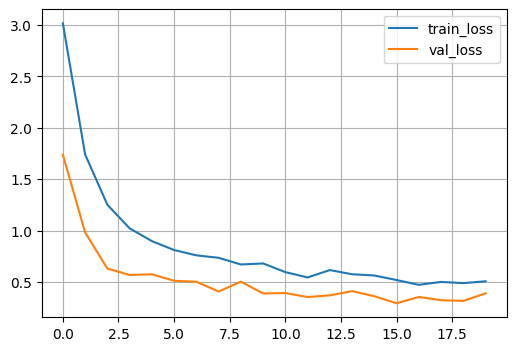

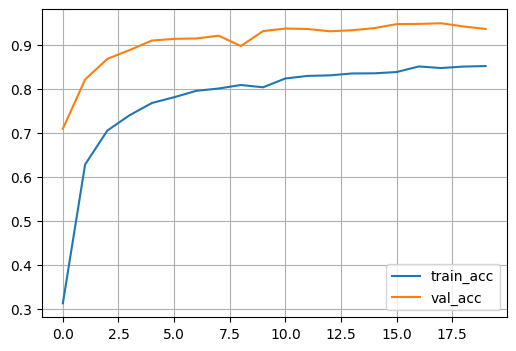

In [93]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.legend()
plt.grid()
plt.show()

## Test

In [94]:
model.load_state_dict(best_state)

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test loss = {test_loss:.4f}, Test acc = {test_acc:.4f}")

Test loss = 0.3154, Test acc = 0.9374


### Prediction

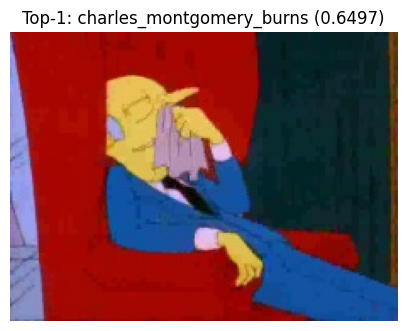

1. charles_montgomery_burns — 0.6497
2. ralph_wiggum — 0.0729
3. homer_simpson — 0.0446
4. snake_jailbird — 0.0405
5. sideshow_bob — 0.0337


In [ ]:
IMG_PATH = './data/simpsons_testset/charles_montgomery_burns_7.jpg'
TOP_K = 5

model.eval()

img = read_image(IMG_PATH)  # [C, H, W], uint8
x = val_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1)

top_probs, top_indices = torch.topk(probs, k=TOP_K, dim=1)

top_probs = top_probs[0].cpu().numpy()
top_indices = top_indices[0].cpu().numpy()

plt.figure(figsize=(5, 5))
plt.imshow(img.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title(f"Top-1: {full_train_dataset.classes[top_indices[0]]} ({top_probs[0]:.4f})")
plt.show()

for rank, (idx, prob) in enumerate(zip(top_indices, top_probs), start=1):
    print(f"{rank}. {full_train_dataset.classes[idx]} — {prob:.4f}")



predict_and_show_single_image(image_path=IMG_PATH, 
                              model=model, 
                              transform=val_transform, 
                              class_names=full_train_dataset.classes, 
                              device=device,
                              topk=5
                              )